# Sushi Go Card Game

In [5]:
# Clone github repository
!git clone https://github.com/wrtubbs3/sushi-go
import sys
sys.path.append('/content/sushi-go')

Cloning into 'sushi-go'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 139 (delta 86), reused 108 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 44.47 KiB | 14.82 MiB/s, done.
Resolving deltas: 100% (86/86), done.


In [14]:
# Imports
from google.colab import files
import urllib.request
import datetime
import statistics
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from game import SushiGo
import config

In [20]:
# To upload files, do the following:
# Open one command prompt and run:
# cd directory_with_pkls
# python -m http.server 8000
# 
# Open a second command prompt and run:
# cloudflared tunnel --url http://localhost:8000
# The terminal will output a random URL to use, which should be pasted below in the urllib lines.
#
# Then run (filling in local IP):
# !wget https://<randomURL>.trycloudflare.com/dqn_agent.pkl
!wget https://female-arctic-last-remind.trycloudflare.com/dqn_agent.pkl
!wget https://female-arctic-last-remind.trycloudflare.com/q_table_4_players.pkl


--2026-01-25 04:39:27--  https://female-arctic-last-remind.trycloudflare.com/dqn_agent.pkl
Resolving female-arctic-last-remind.trycloudflare.com (female-arctic-last-remind.trycloudflare.com)... 104.16.230.132, 104.16.231.132, 2606:4700::6810:e784, ...
Connecting to female-arctic-last-remind.trycloudflare.com (female-arctic-last-remind.trycloudflare.com)|104.16.230.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 449530 (439K) [application/octet-stream]
Saving to: ‘dqn_agent.pkl.1’

dqn_agent.pkl.1     100%[===================>] 438.99K  --.-KB/s    in 0.1s    

2026-01-25 04:39:28 (3.15 MB/s) - ‘dqn_agent.pkl.1’ saved [449530/449530]

--2026-01-25 04:39:28--  https://female-arctic-last-remind.trycloudflare.com/q_table_4_players.pkl
Resolving female-arctic-last-remind.trycloudflare.com (female-arctic-last-remind.trycloudflare.com)... 104.16.230.132, 104.16.231.132, 2606:4700::6810:e684, ...
Connecting to female-arctic-last-remind.trycloudflare.com (female-ar

[INFO] Using device: cuda
[INFO] Agent loaded from q_table_4_players.pkl (games_trained=1000000, q_size=6961172)
[INFO] Bob loaded Q-table from q_table_4_players.pkl


 10%|█         | 10001/100000 [14:31<2:18:38, 10.82it/s]

[INFO] Deep Q agent saved to dqn_agent.pkl (steps=240000)


 20%|██        | 20001/100000 [29:10<2:00:47, 11.04it/s]

[INFO] Deep Q agent saved to dqn_agent.pkl (steps=480000)


...

[INFO] Deep Q agent saved to dqn_agent.pkl (steps=1920000)


 90%|█████████ | 90002/100000 [2:09:41<14:57, 11.14it/s]

[INFO] Deep Q agent saved to dqn_agent.pkl (steps=2160000)


100%|██████████| 100000/100000 [2:24:07<00:00, 11.56it/s]


[INFO] Deep Q agent saved to dqn_agent.pkl (steps=2400000)
[INFO] Deep Q agent saved to dqn_agent.pkl (steps=2400000)
Al finished with 2392654 points using the deep q-learning strategy.
Al finished with an average score of 23.93 points using the deep q-learning strategy.
Al finished with standard deviation of 8.76 points using the deep q-learning strategy.
Bob finished with 3590087 points using the q-learning strategy.
Bob finished with an average score of 35.9 points using the q-learning strategy.
Bob finished with standard deviation of 6.65 points using the q-learning strategy.
Charlie finished with 2946254 points using the hierarchy strategy.
Charlie finished with an average score of 29.46 points using the hierarchy strategy.
Charlie finished with standard deviation of 7.77 points using the hierarchy strategy.
Doug finished with 2899664 points using the hierarchy strategy.
Doug finished with an average score of 29.0 points using the hierarchy strategy.
Doug finished with standard de

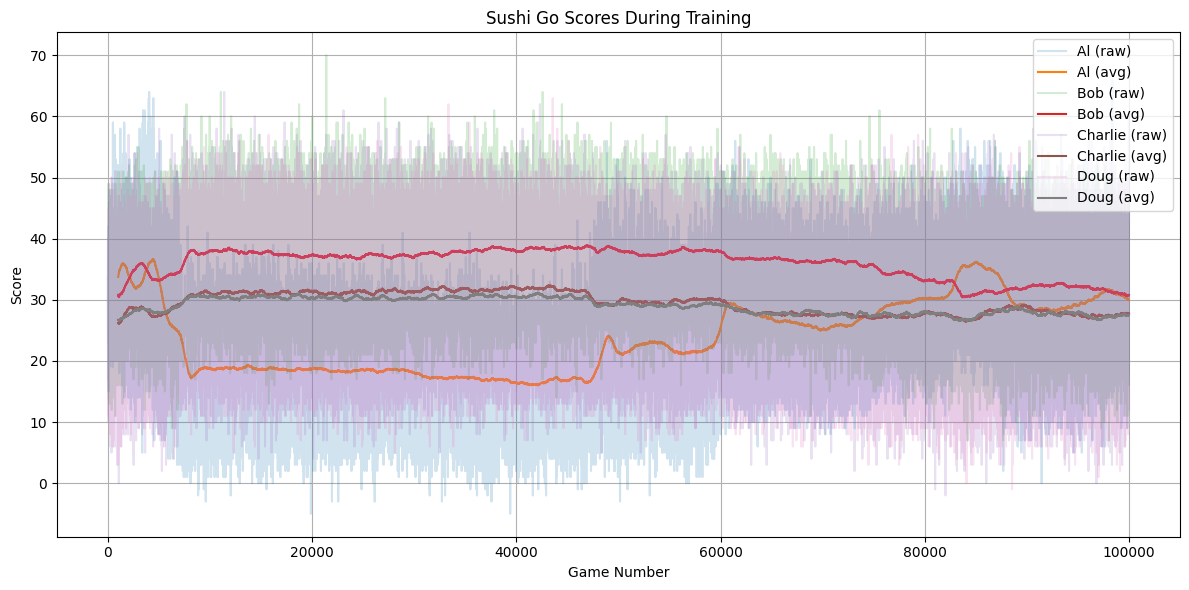

[INFO] Plot saved as sushi_go_training_20260125_071234.png


In [21]:
# From 2-5 players allowed
player_names = ['Al', 'Bob', 'Charlie', 'Doug']
n_players = len(player_names)
player_strategies = ['deep q-learning', 'q-learning', 'hierarchy', 'hierarchy']
player_qtables = ['dqn_agent.pkl', 'q_table_4_players.pkl', None, None]  # only used for q-learning

# Create game
game = SushiGo(n_players, player_names, player_strategies, player_qtables=player_qtables)

# Collect references to any trainable agents
trainable_agents = []
for p in game.players:
    if p.strategy == "q-learning":
        p.agent.train = False
        if p.agent.train == True:
            trainable_agents.append(p.agent)
    elif p.strategy == "deep q-learning":
        p.agent.train = True
        if p.agent.train == True:
            trainable_agents.append(p.agent)

# Number of games to simulate
n_games = int(1e5)

# Initialize game log for statistical tracking
game_score_log = [[] for _ in range(n_players)]

# Filenames for saving agents
q_table_filename = "q_table"
dqn_filename = "dqn_agent"

# Simulate games
for i in tqdm(range(n_games)):
    game_score = game.play_game()

    for j in range(n_players):
        game_score_log[j].append(game_score[j])

    for agent in trainable_agents:
        agent.games_trained += 1

    # Periodically save agents
    save_interval = config.params['save_every']
    if (i + 1) % save_interval == 0:
        for agent in trainable_agents:
            if agent.__class__.__name__ == "QLearningAgent":
                agent.save(q_table_filename)
            elif agent.__class__.__name__ == "DeepQLearningAgent":
                agent.save(dqn_filename)

# Save final versions
for agent in trainable_agents:
    if agent.__class__.__name__ == "QLearningAgent":
        agent.save(q_table_filename)
    elif agent.__class__.__name__ == "DeepQLearningAgent":
        agent.save(dqn_filename)

# Compute statistics for each player
total_score = []
avg_game_score = []
stdev_game_score = []
for i in range(n_players):
    total_score.append(sum(game_score_log[i]))
    avg_game_score.append(round(total_score[i] / n_games, 2))
    stdev_game_score.append(round(statistics.pstdev(game_score_log[i]), 2))

# Print results for each player
for i in range(n_players):
    print(player_names[i], 'finished with', total_score[i], 'points using the', player_strategies[i], 'strategy.')
    # print('Game log: ', game_score_log[i])
    print(player_names[i], 'finished with an average score of', avg_game_score[i], 'points using the', player_strategies[i], 'strategy.')
    print(player_names[i], 'finished with standard deviation of', stdev_game_score[i], 'points using the', player_strategies[i], 'strategy.')    

# ---------------------------------------------------
# Plotting raw and smoothed scores
# ---------------------------------------------------

plt.figure(figsize=(12, 6))
for i in range(n_players):
    raw_scores = np.array(game_score_log[i])

    # Smoothed (rolling average with window)
    window = int(n_games/100) if n_games >= 100 else 1
    smoothed = np.convolve(raw_scores, np.ones(window)/window, mode='valid')

    plt.plot(range(1, len(raw_scores)+1), raw_scores, alpha=0.2, label=f"{player_names[i]} (raw)")
    plt.plot(range(window, len(raw_scores)+1), smoothed, label=f"{player_names[i]} (avg)")

plt.xlabel("Game Number")
plt.ylabel("Score")
plt.title("Sushi Go Scores During Training")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Add timestamp to filename
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"sushi_go_training_{timestamp}.png"

# Save plot as PNG
plt.savefig(filename, dpi=300)

# Show on screen
plt.show()

print(f"[INFO] Plot saved as {filename}")


In [ ]:
files.download(filename)
files.download('dqn_agent.pkl')